# SVM Classification on the Iris Dataset

This notebook uses the Support Vector Machine (SVM) algorithm to classify flowers from the Iris dataset. We will test different kernel types to see which one works best, and then evaluate the model with the same metrics we used for KNN.

By running both KNN and SVM on the same dataset with the same split, we can directly compare how the two algorithms perform.

## Step 1: Import Libraries

We need the same data tools as before, plus the SVM classifier from sklearn.

In [1]:
# Import the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools from sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

## Step 2: Load and Prepare the Data

We load the Iris dataset and prepare it the same way as the KNN notebook. We use the same random_state (42) so the train/test split is identical. This way the comparison between KNN and SVM is fair.

In [2]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Show the first few rows
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Separate features and target
X = df.drop('species', axis=1)
y = df['species']

# Split into training and testing (same split as KNN notebook)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape[0], "samples")
print("Testing set:", X_test.shape[0], "samples")

Training set: 120 samples
Testing set: 30 samples


### Scaling the Features

Just like KNN, SVM also benefits from scaling. SVM tries to find the best boundary (hyperplane) between classes, and if features have different scales, the boundary will be skewed toward the features with bigger numbers.

In [4]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


## Step 3: How SVM Works

SVM stands for Support Vector Machine. The idea is simple: find the best line (or boundary) that separates different classes of data. In 2D, this boundary is a line. In higher dimensions, it is called a **hyperplane**.

SVM does not just find any boundary. It finds the one that has the **maximum margin**, meaning the boundary is as far as possible from the nearest data points of each class. The data points closest to the boundary are called **support vectors** because they are the ones that define where the boundary goes.

### Kernels

Sometimes the data cannot be separated by a straight line. Kernels are a way to transform the data into a higher dimension where a straight boundary can work. We will test three kernels:
- **Linear**: draws a straight boundary (works when classes are already well separated)
- **RBF (Radial Basis Function)**: creates curved boundaries (good for more complex patterns)
- **Polynomial**: creates boundaries using polynomial curves

## Step 4: Test Different SVM Kernels

We will train an SVM model with each of the three kernels and see which one gives the best accuracy on the Iris dataset.

In [5]:
# Test different SVM kernels
kernels = ['linear', 'rbf', 'poly']
kernel_accuracies = []

for kernel in kernels:
    # Create an SVM model with this kernel
    svm_model = SVC(kernel=kernel, random_state=42)

    # Train the model
    svm_model.fit(X_train_scaled, y_train)

    # Make predictions
    predictions = svm_model.predict(X_test_scaled)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, predictions)
    kernel_accuracies.append(accuracy)

    print("Kernel: {:10s} |  Accuracy = {:.4f}".format(kernel, accuracy))

Kernel: linear     |  Accuracy = 0.9667
Kernel: rbf        |  Accuracy = 1.0000
Kernel: poly       |  Accuracy = 0.9667


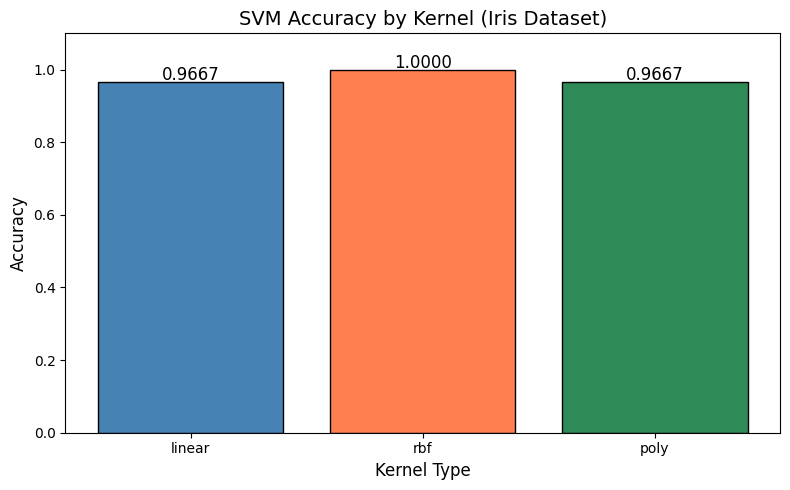

In [6]:
# Plot accuracy for each kernel
plt.figure(figsize=(8, 5))
bars = plt.bar(kernels, kernel_accuracies, color=['steelblue', 'coral', 'seagreen'], edgecolor='black')

# Add accuracy labels on top of each bar
for bar, acc in zip(bars, kernel_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             "{:.4f}".format(acc), ha='center', fontsize=12)

plt.xlabel('Kernel Type', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('SVM Accuracy by Kernel (Iris Dataset)', fontsize=14)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [7]:
# Find the best kernel
best_kernel_index = kernel_accuracies.index(max(kernel_accuracies))
best_kernel = kernels[best_kernel_index]

print("Best kernel:", best_kernel)
print("Best accuracy: {:.4f}".format(max(kernel_accuracies)))

Best kernel: rbf
Best accuracy: 1.0000


## Step 5: Final Model Evaluation

We will train the final SVM model with the best kernel and look at all the evaluation metrics.

In [8]:
# Train the final SVM model with the best kernel
final_svm = SVC(kernel=best_kernel, random_state=42)
final_svm.fit(X_train_scaled, y_train)

# Make predictions
final_predictions = final_svm.predict(X_test_scaled)

# Calculate all metrics
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions, average='weighted')
recall = recall_score(y_test, final_predictions, average='weighted')
f1 = f1_score(y_test, final_predictions, average='weighted')

print("=== Final SVM Model Results (kernel = {}) ===".format(best_kernel))
print()
print("Accuracy:  {:.4f}".format(accuracy))
print("Precision: {:.4f}".format(precision))
print("Recall:    {:.4f}".format(recall))
print("F1 Score:  {:.4f}".format(f1))

=== Final SVM Model Results (kernel = rbf) ===

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


### Confusion Matrix

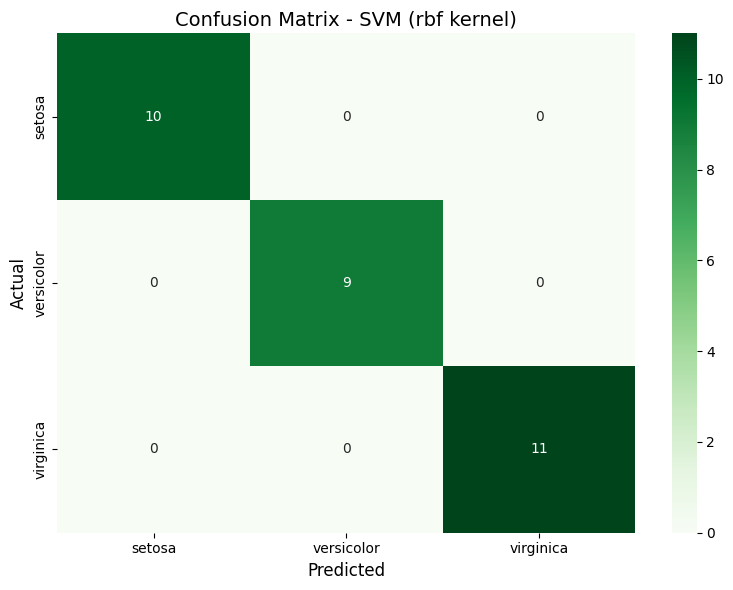

In [9]:
# Create and plot the confusion matrix
cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - SVM ({} kernel)'.format(best_kernel), fontsize=14)
plt.tight_layout()
plt.show()

### Classification Report

In [10]:
# Print the full classification report
print("Classification Report:")
print()
print(classification_report(y_test, final_predictions, target_names=iris.target_names))

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Step 6: KNN vs SVM Comparison on Iris

Now we can compare how KNN and SVM performed on the same Iris dataset with the same train/test split. Both algorithms had access to the same data, so any difference in results comes from how the algorithms work.

Key differences between the two:
- **KNN** makes predictions by finding the K closest training points and taking a vote. It does not learn a boundary — it just remembers the data. This is called a **lazy learner**.
- **SVM** actually learns a boundary (hyperplane) during training that separates the classes. It is called an **eager learner** because it does the work upfront.

For a clean, well-separated dataset like Iris, both algorithms tend to perform very well. The real differences show up on harder datasets where the data is noisier or the classes overlap more. We will see that when we run both algorithms on the Diabetes dataset.

## Summary

In this notebook we used SVM to classify Iris flowers. Here is what we did:

1. Loaded the same Iris dataset and used the same train/test split as the KNN notebook
2. Scaled the features for fair distance-based calculations
3. Tested three kernel types: linear, RBF, and polynomial
4. Found the best kernel and evaluated the final model
5. Produced accuracy, precision, recall, F1, confusion matrix, and classification report

The Iris dataset is clean and well-separated, so both KNN and SVM achieve high accuracy. The Diabetes dataset will be a better test of which algorithm handles complexity better.